# Hyperion Economy — Juno Demo

Diese kompakte Demo läuft lokal auf dem iPad. Sie zeigt in wenigen Schritten, wie Produktion, Handel, Ereignisse und Time Debt zusammenwirken.

Die Standardausführung ist bewusst klein und reproduzierbar: 20 Jahre, drei Läufe, feste Seeds und Matplotlib-Grafiken.

In [1]:
from IPython.display import display
import matplotlib.pyplot as plt
from juno_demo import (
    DEFAULT_RUNS, DEFAULT_SEED, DEFAULT_YEARS, SCENARIOS,
    environment_report, export_demo, kpi_table, plot_dashboard,
    plot_good_detail, plot_world_detail, run_simulation, scenario_table,
)

display(environment_report())


,item,available,detail
0,Python,True,3.13.7
1,Working directory,True,/private/var/mobile/Containers/Shared/AppGroup...
2,pandas,True,installed
3,matplotlib,True,installed
4,ipywidgets,True,installed
5,pyarrow,True,installed


## 1. Ausgangslage

Wir starten mit einer normalen Wirtschaftsentwicklung. Die Ergebnisse werden als kompakte Tabellen gehalten, damit das Notebook auf dem iPad schnell reagiert.

In [2]:
frames = run_simulation(
    years=DEFAULT_YEARS,
    seed=DEFAULT_SEED,
    num_runs=DEFAULT_RUNS,
    scenario="baseline",
)
display(kpi_table(frames))


,scenario,run,final_year,final_prosperity,final_stability,final_cash,final_time_debt,total_trade_volume,total_trade_value,event_count
0,baseline,1,20,0.70,0.20,0.00,5.27,358.94,12883.04,8
1,baseline,2,20,0.86,0.40,361.08,12.37,376.29,14570.28,12
2,baseline,3,20,0.81,0.38,0.00,11.68,367.24,13900.21,5


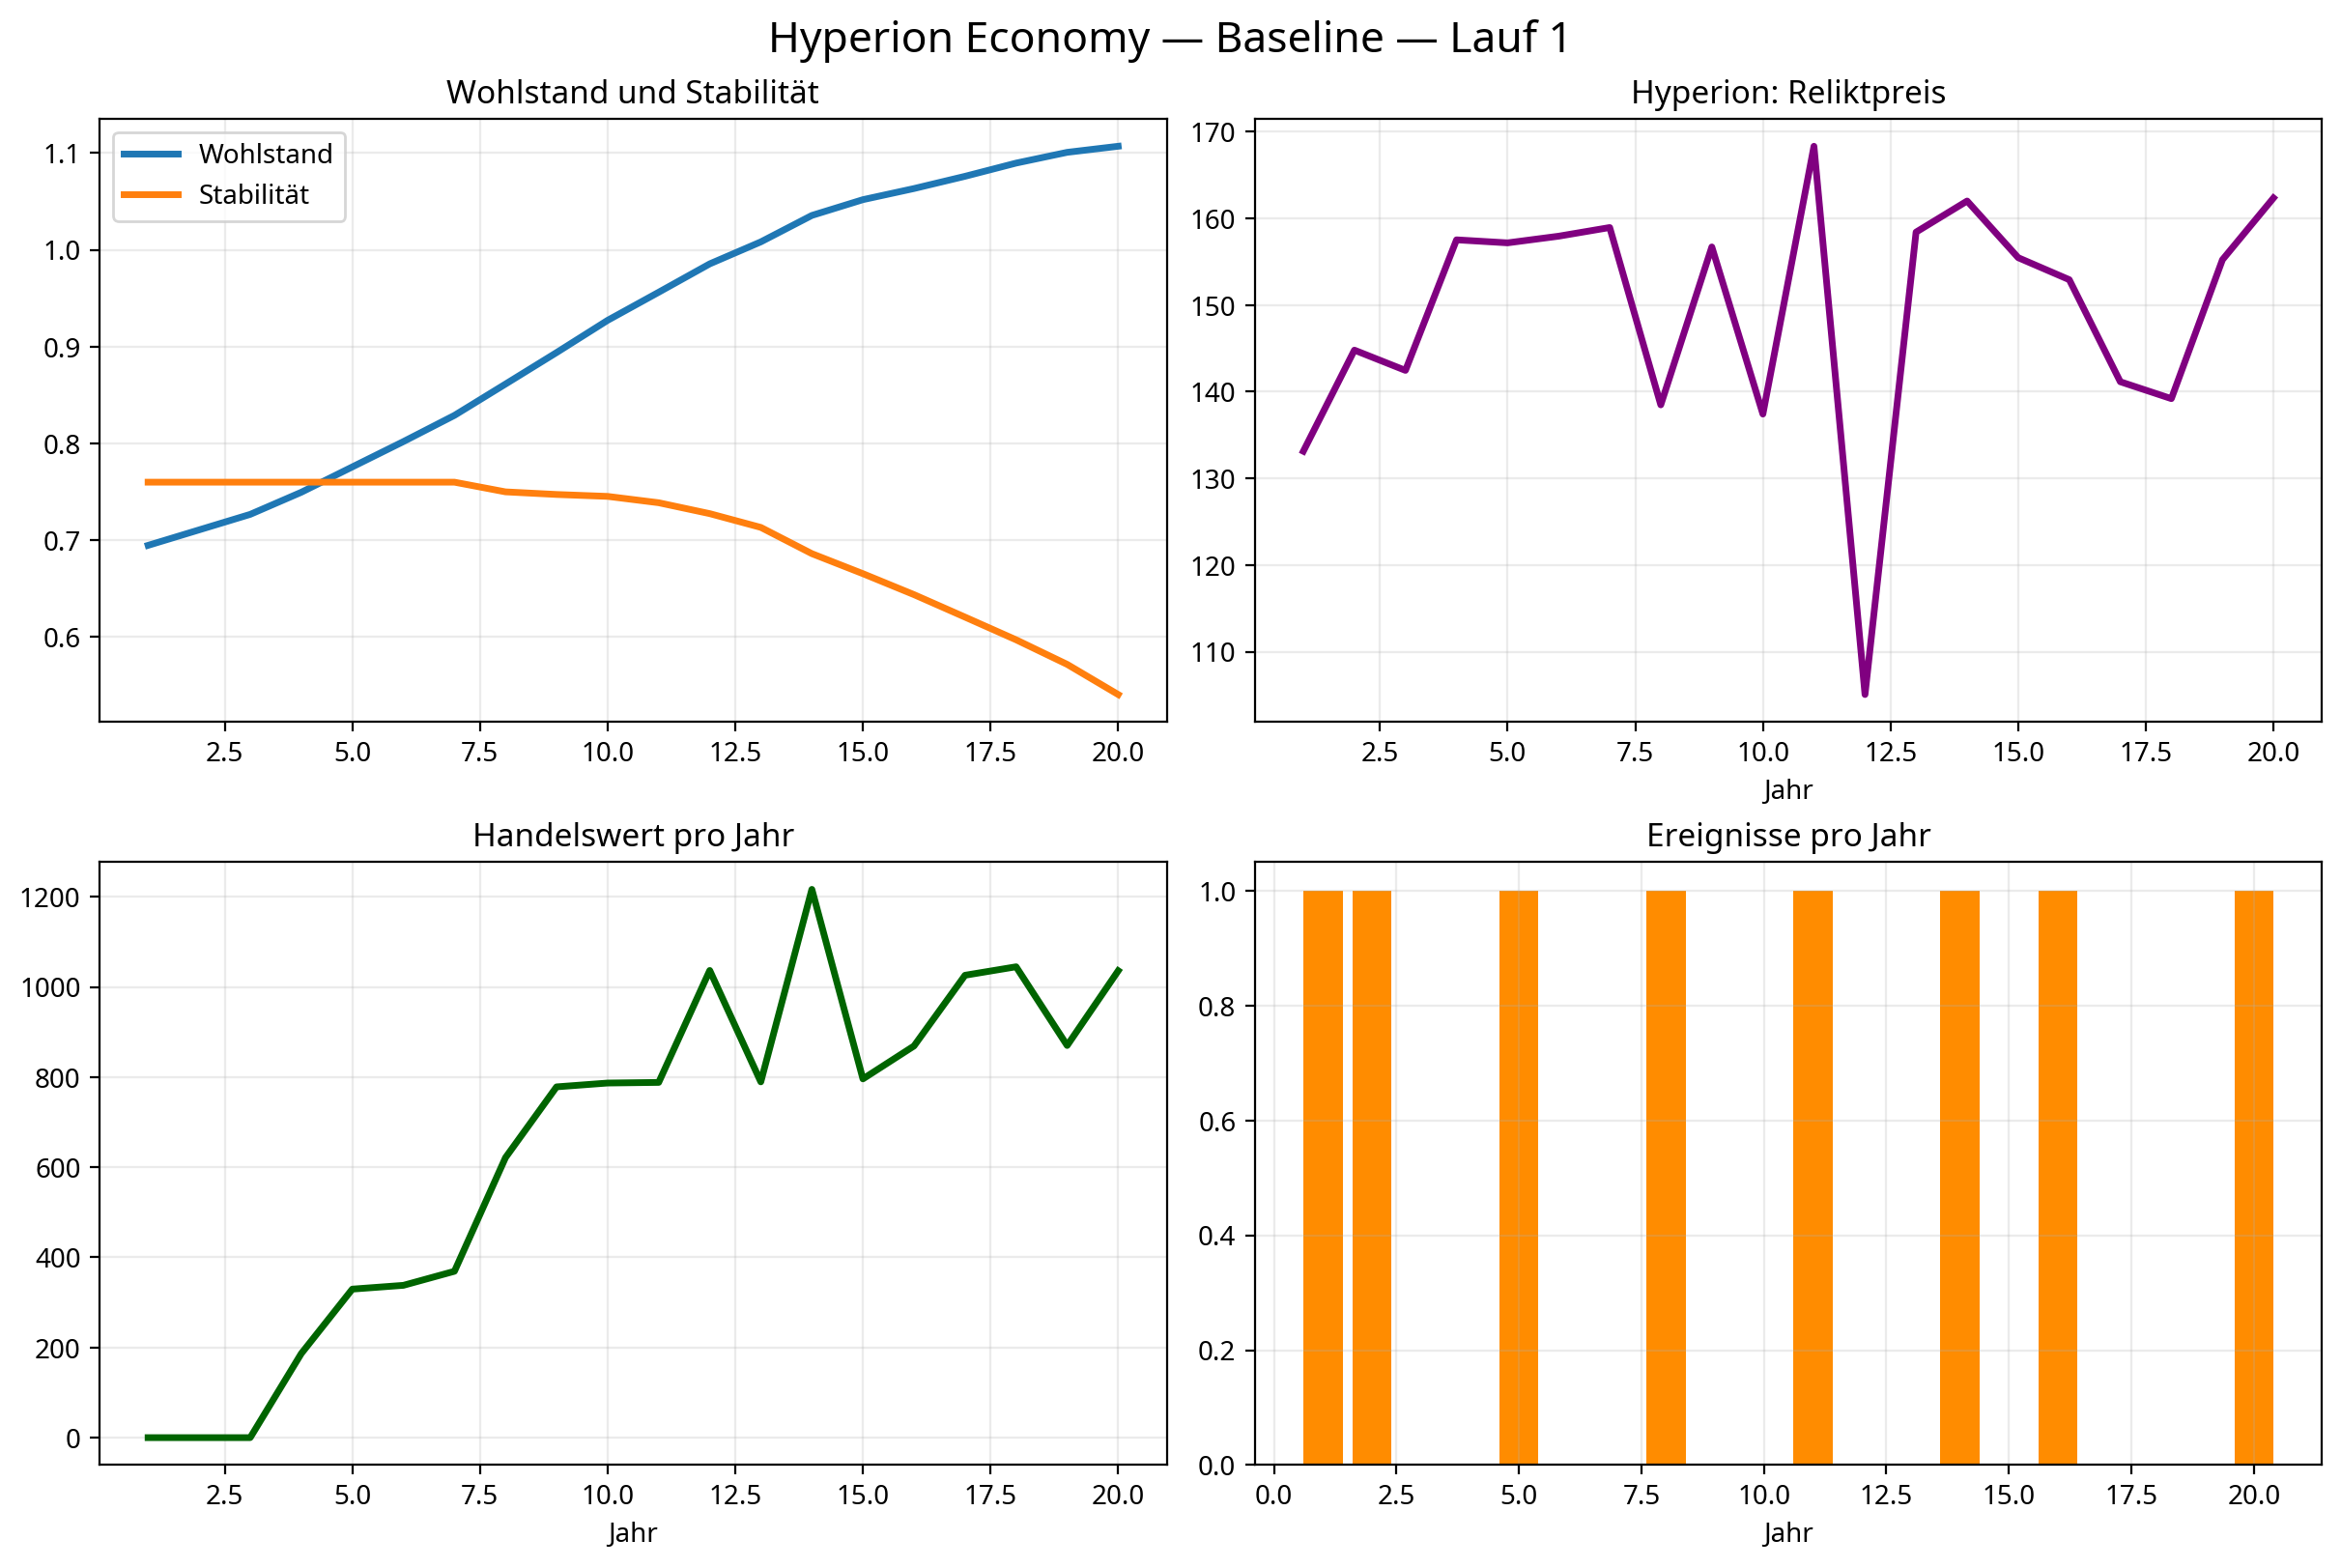

In [3]:
fig, axes = plot_dashboard(frames, run=1)
plt.show()


## 2. Drei Geschichten im direkten Vergleich

Die Szenarien verwenden feste Seeds und erzwingen ein Ereignis im dritten Jahr. Dadurch ist die Demo vor Publikum jederzeit nachvollziehbar.

In [4]:
display(scenario_table(years=DEFAULT_YEARS))


,scenario,final_prosperity,final_stability,total_trade_value,final_time_debt
0,Baseline,0.70,0.20,12883.04,5.27
1,Farcaster-Ausfall,0.77,0.37,13367.44,7.51
2,Pilgerboom,0.88,0.46,14044.14,10.23


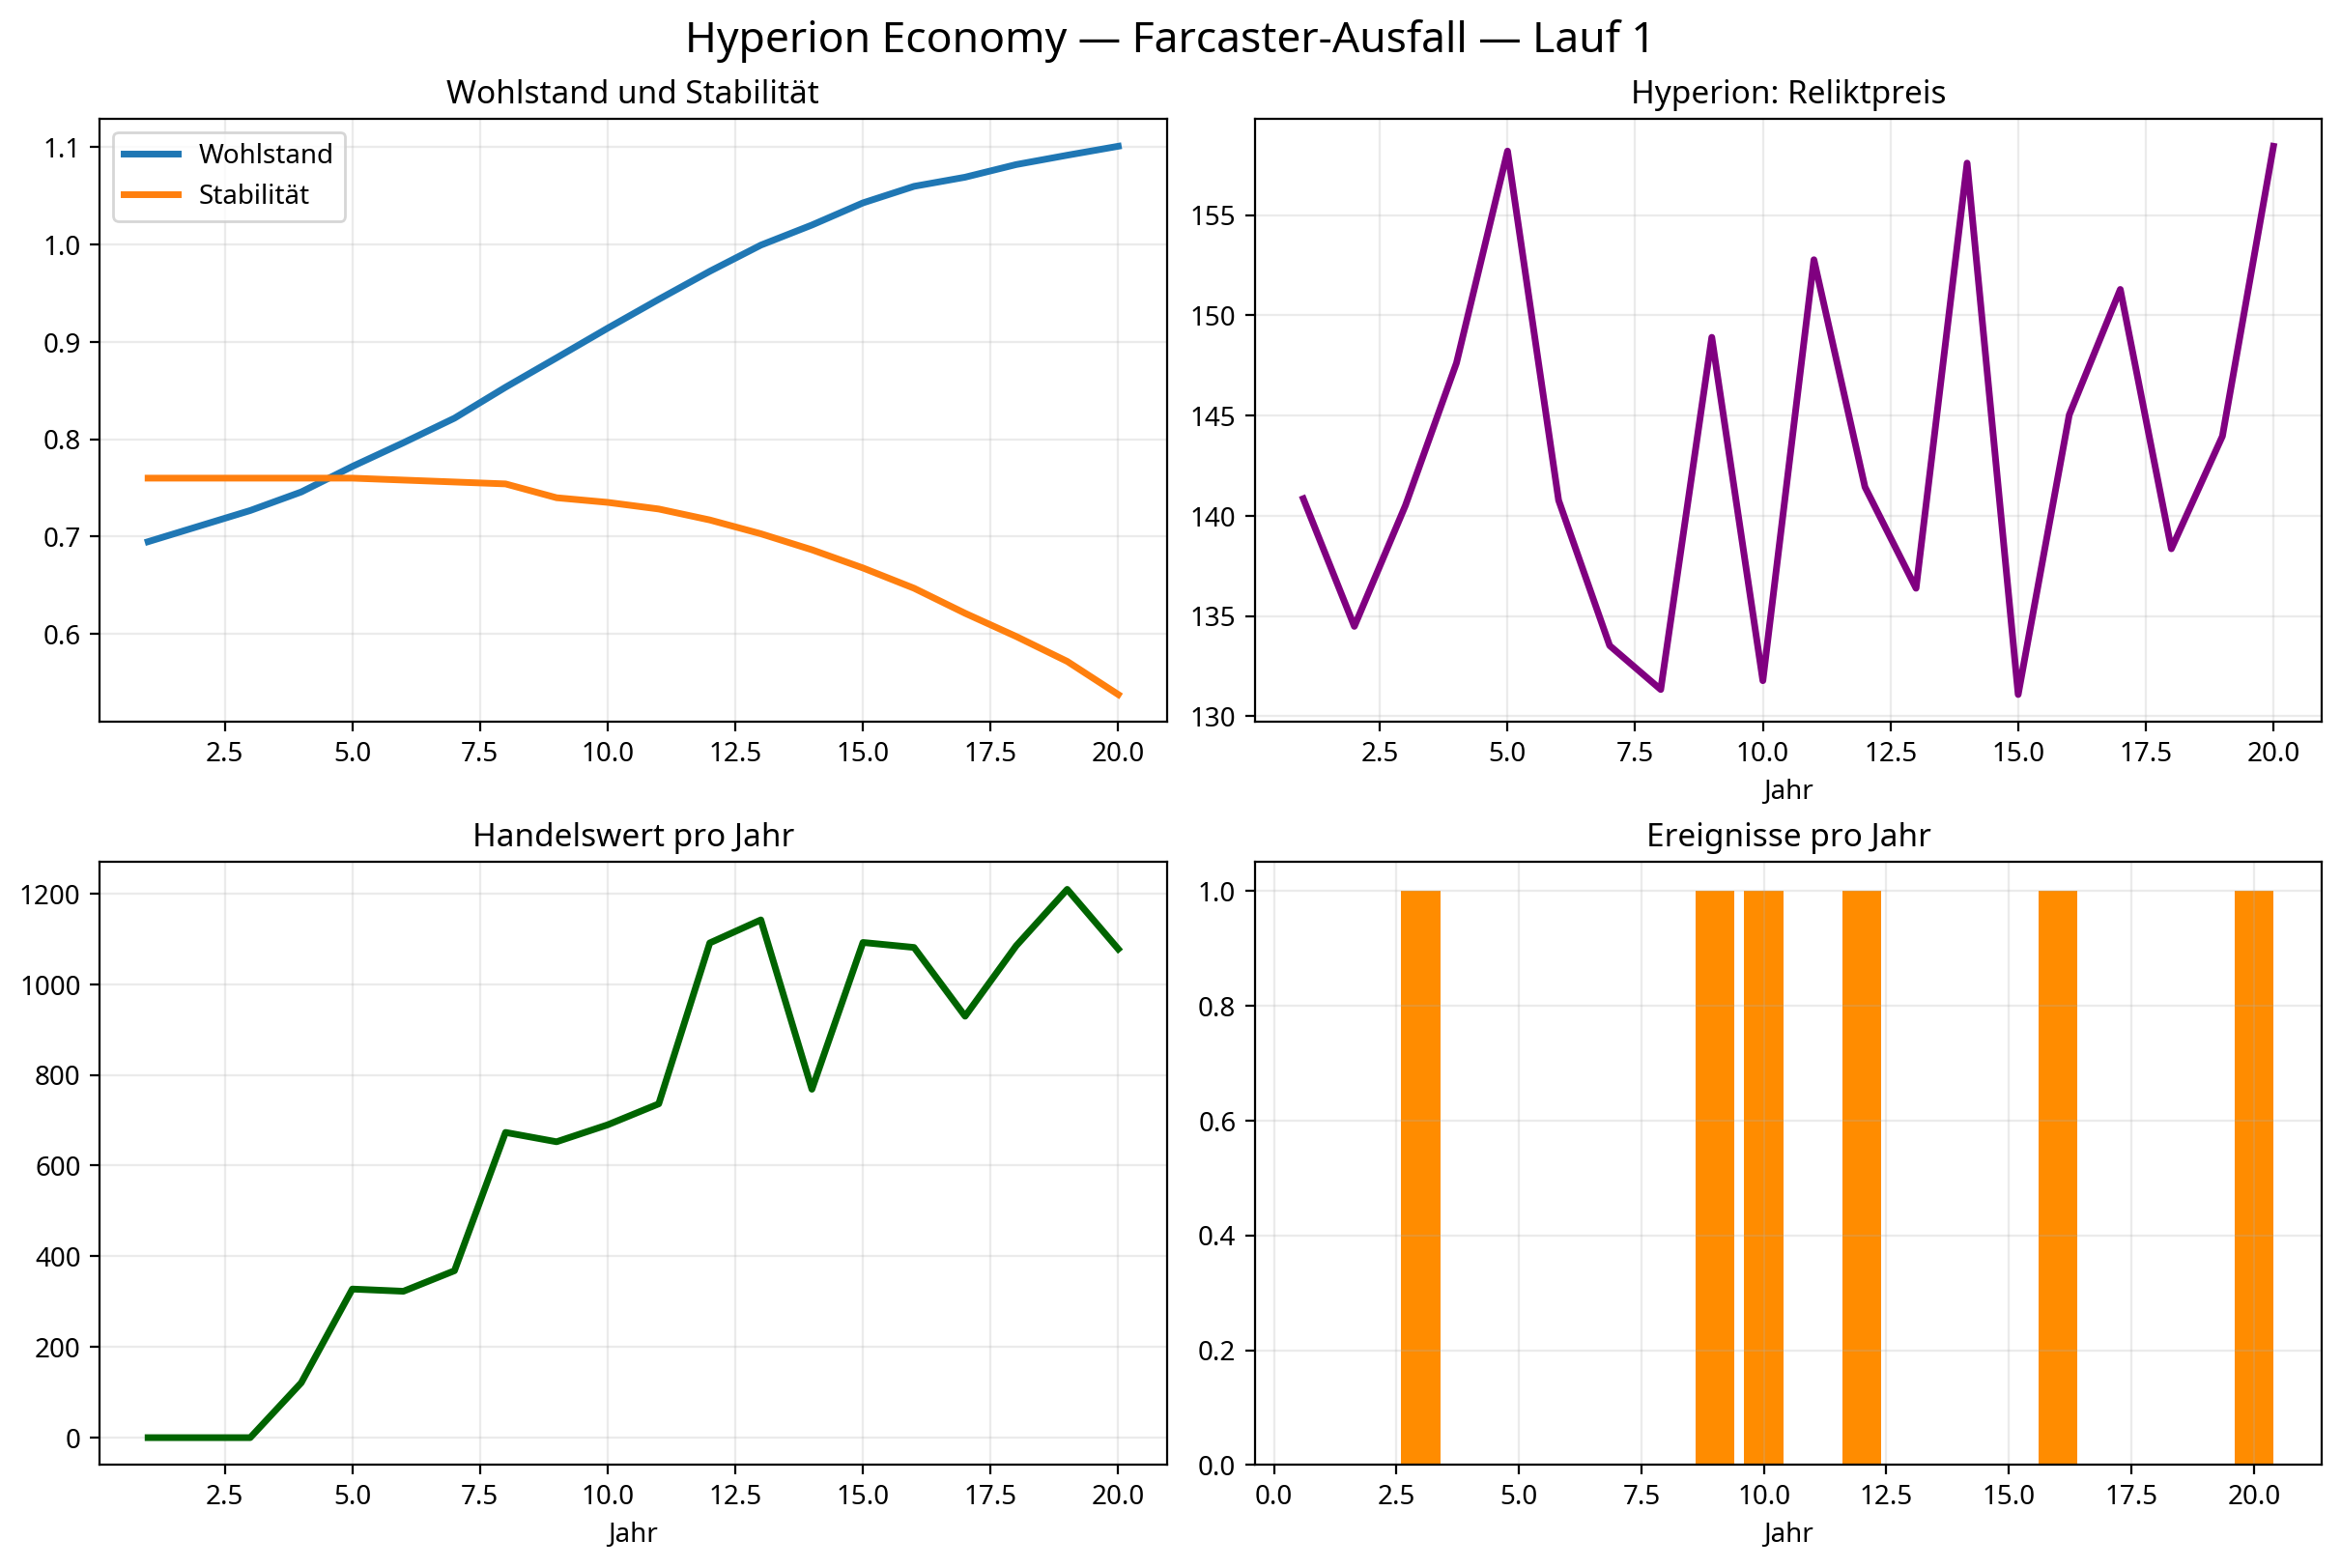

In [5]:
farcaster_frames = run_simulation(years=DEFAULT_YEARS, seed=17, num_runs=1, scenario="farcaster")
fig, axes = plot_dashboard(farcaster_frames, run=1)
plt.show()


## 3. Welt und Gut untersuchen

Hyperion ist der beste Einstiegspunkt: Relikte zeigen die Nachfragewirkung, Time Debt zeigt die Kosten schlechter Routen.

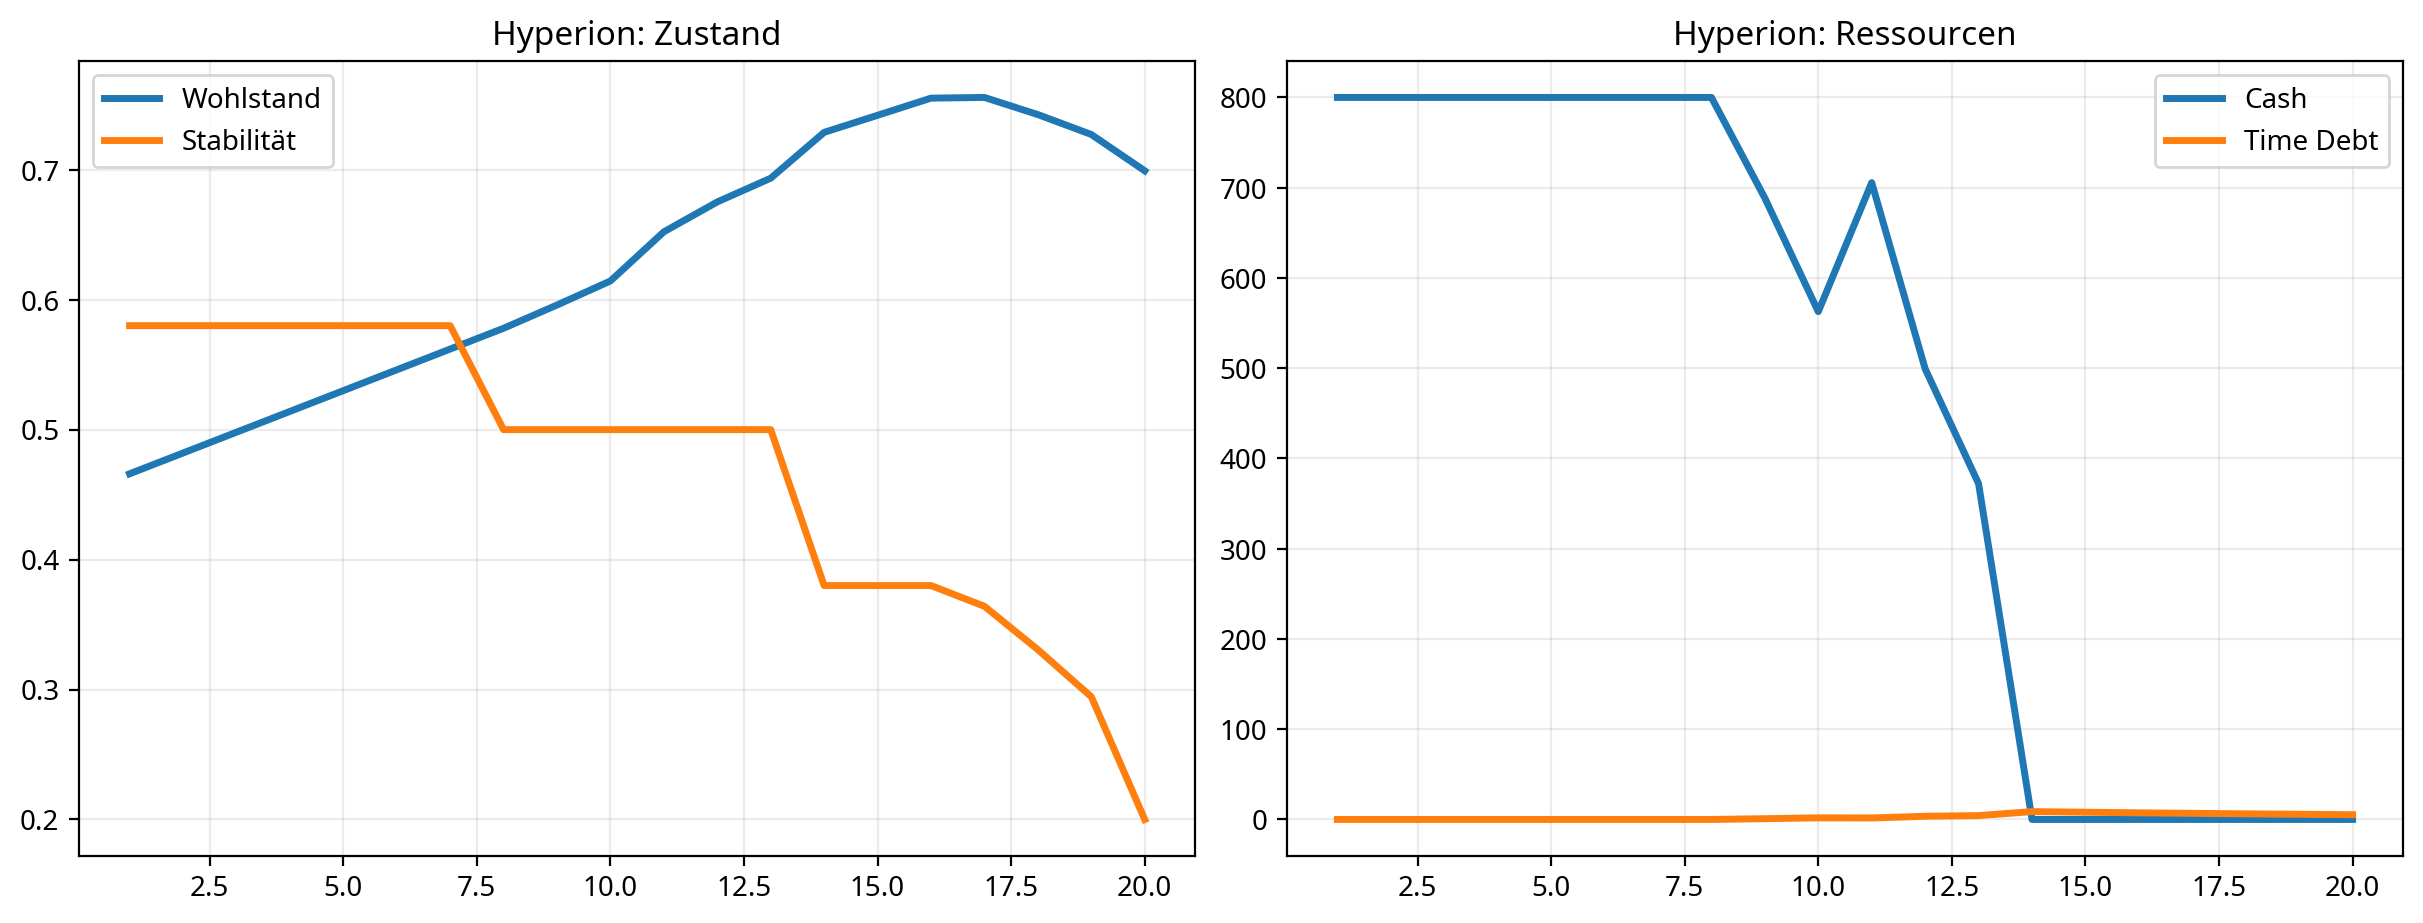

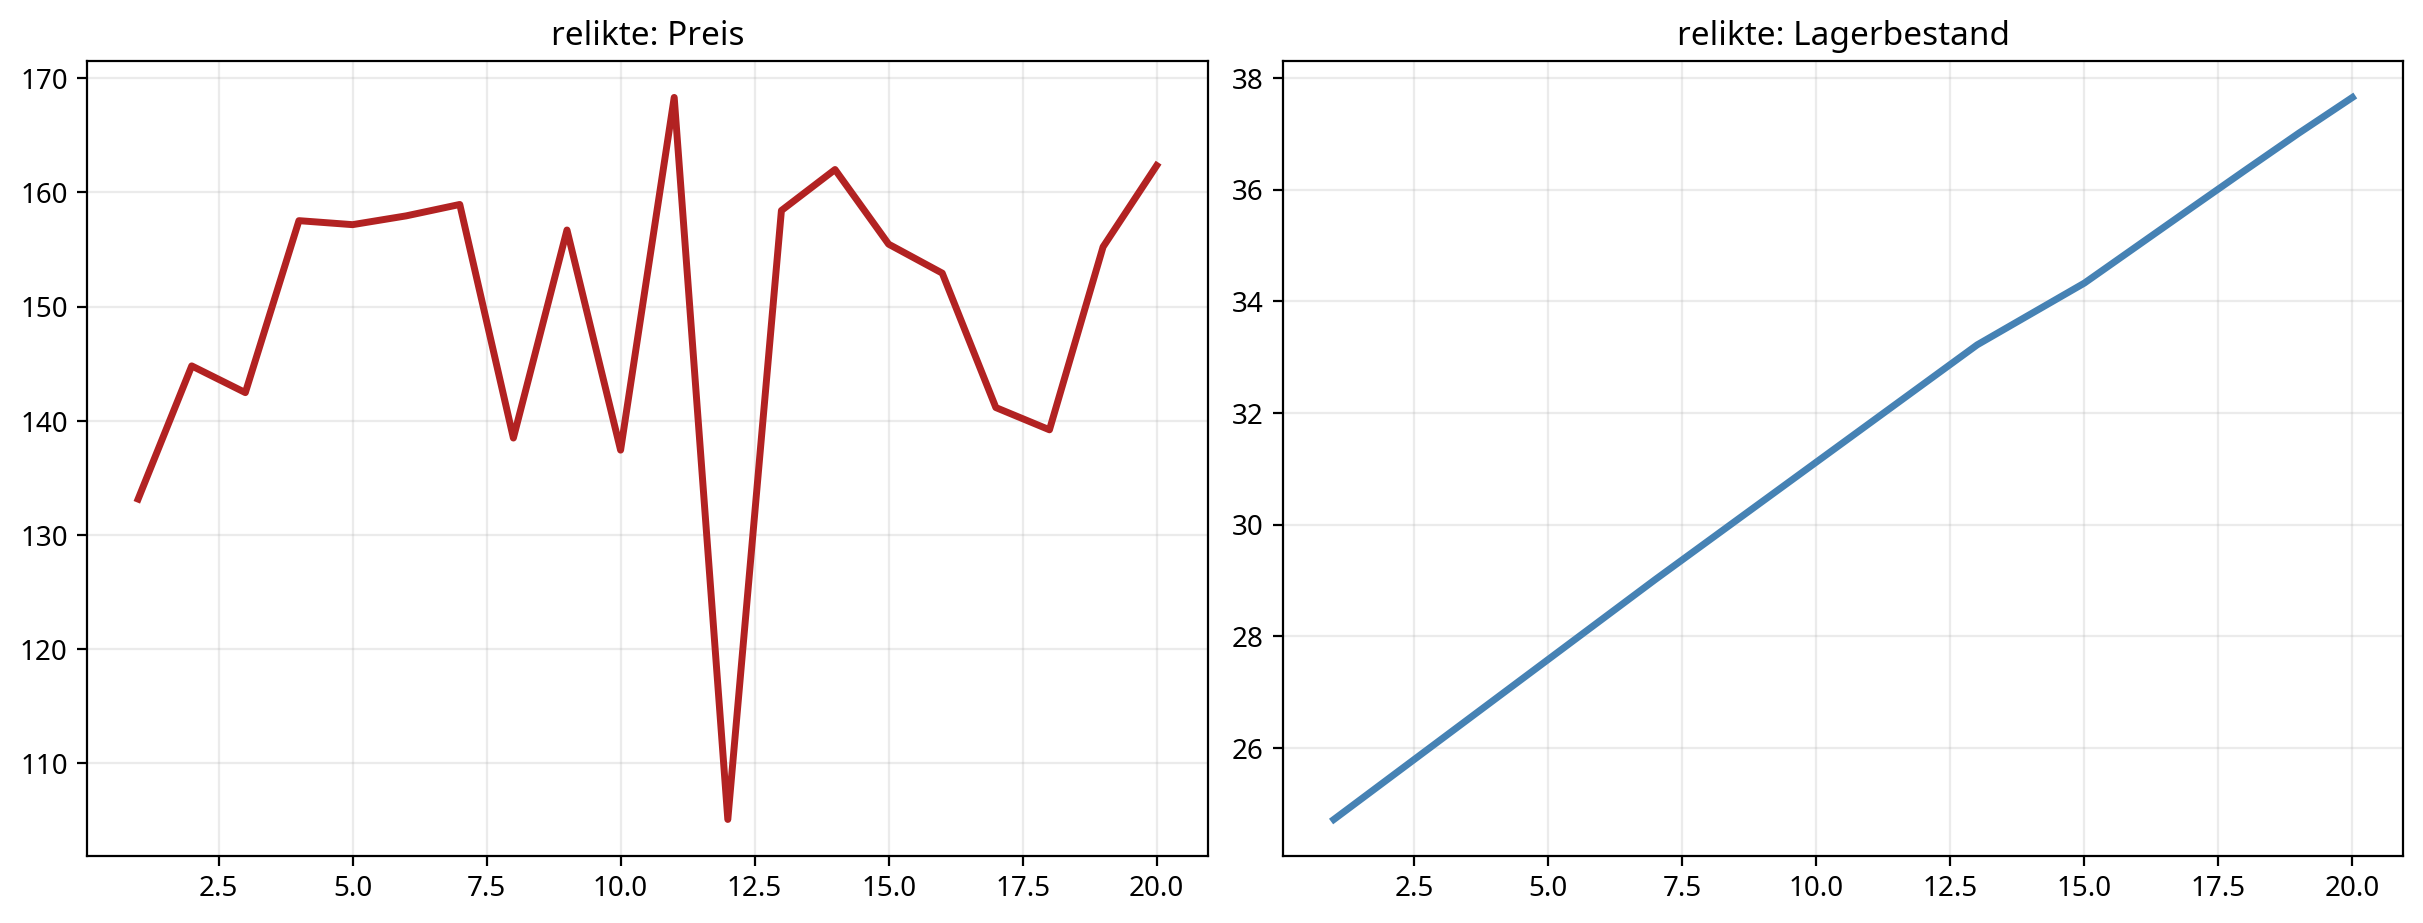

In [6]:
fig, axes = plot_world_detail(frames, world_name="Hyperion", run=1)
plt.show()
fig, axes = plot_good_detail(frames, good="relikte", world_name="Hyperion", run=1)
plt.show()


## 4. Interaktive Steuerung

Die Widgets sind optional. Wenn Juno keine Widget-Erweiterung anbietet, bleibt die Demo vollständig über die Parameterzellen nutzbar.

In [7]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    years_control = widgets.IntSlider(value=20, min=5, max=40, step=5, description="Jahre")
    seed_control = widgets.IntSlider(value=7, min=1, max=99, step=1, description="Seed")
    event_control = widgets.FloatSlider(value=0.45, min=0, max=1, step=0.05, description="Events")
    trade_control = widgets.FloatSlider(value=1.0, min=0.25, max=2.0, step=0.25, description="Handel")
    scenario_control = widgets.Dropdown(options=list(SCENARIOS), value="baseline", description="Szenario")
    world_control = widgets.Dropdown(options=sorted(frames["world"]["world"].unique()), value="Hyperion", description="Welt")
    good_control = widgets.Dropdown(options=sorted(frames["price"]["good"].unique()), value="relikte", description="Gut")
    run_button = widgets.Button(description="Demo ausführen", button_style="success")
    output = widgets.Output()

    def refresh(_=None):
        with output:
            clear_output(wait=True)
            selected = run_simulation(
                years=years_control.value, seed=seed_control.value, num_runs=1,
                event_chance=event_control.value, trade_intensity=trade_control.value,
                scenario=scenario_control.value,
            )
            display(kpi_table(selected))
            plot_dashboard(selected, run=1)
            plt.show()
            plot_world_detail(selected, world_control.value, run=1)
            plt.show()
            plot_good_detail(selected, good_control.value, world_control.value, run=1)
            plt.show()

    run_button.on_click(refresh)
    display(widgets.VBox([years_control, seed_control, event_control, trade_control, scenario_control, world_control, good_control, run_button, output]))
except ImportError:
    print("ipywidgets ist optional. Verwende die Parameterzellen für den Demo-Lauf.")


## 5. Ergebnisse exportieren

CSV-Dateien sind der portable Standard. Parquet wird nur zusätzlich erzeugt, wenn Juno eine passende Engine installiert hat.

In [8]:
export_demo(
    frames,
    output_dir="demo_exports",
    metadata={"scenario": "baseline", "years": DEFAULT_YEARS, "runs": DEFAULT_RUNS},
)


{'csv_files': ['demo_exports/yearly.csv',
  'demo_exports/world.csv',
  'demo_exports/price.csv',
  'demo_exports/events.csv',
  'demo_exports/trades.csv',
  'demo_exports/kpis.csv'],
 'parquet_files': ['demo_exports/yearly.parquet',
  'demo_exports/world.parquet',
  'demo_exports/price.parquet',
  'demo_exports/events.parquet',
  'demo_exports/trades.parquet'],
 'metadata': 'demo_exports/metadata.json'}

## Kernaussagen für die Präsentation

- Farcaster-Ausfälle erhöhen Kosten und Time Debt.
- Pilgerströme treiben Luxus- und Reliktnachfrage.
- Stabilität, Lagerbestand und Handel beeinflussen sich gegenseitig.
- Derselbe Seed liefert dieselbe Geschichte — ideal für eine Live-Demo.

Für einen kurzen Vortrag genügen die Zellen 1 bis 3; die Widgets und Exporte sind die interaktive Vertiefung.